In [21]:
import os, glob, argparse, json, csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [22]:
def parse_fractions(frac_arg: str | None):
    if frac_arg:
        return [float(x) for x in frac_arg.split(",")]
    # default ladder: 0.05, 0.1, 0.2, ..., 1.0
    return [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def best_row(df: pd.DataFrame) -> pd.Series:
    if "final_val_mse" in df.columns and df["final_val_mse"].notna().any():
        return df.loc[df["final_val_mse"].astype(float).idxmin()]
    # fallback to early-stopping metric if needed
    return df.loc[df["best_val_loss"].astype(float).idxmin()]

def parse_frac_from_dir(sel_dir: Path):
    # sel_dir.name like "sel_frac_0.05" or "sel_frac_1.0"
    try:
        return float(sel_dir.name.split("sel_frac_")[1])
    except Exception:
        return None

def best_row_from_csv(csv_path: Path):
    best = None
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                v = float(row["final_val_mse"])
            except Exception:
                continue
            if (best is None) or (v < float(best["final_val_mse"])):
                best = row
    return best

In [27]:
output_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"

In [28]:
ap = argparse.ArgumentParser()
ap.add_argument("--output_dir", required=True, help="Root run dir used by decoding script")
ap.add_argument("--fractions", default=None, help="Comma-separated list, e.g. '0.05,0.1,0.2,...,1'")
ap.add_argument("--out_csv", default="best_per_fraction.csv")
ap.add_argument("--out_dir", default=None, help="Where to save CSV/plots (defaults to analysis/initial_tokens)")
args = ap.parse_args([
    "--output_dir", f"{output_dir}",
])

fracs = parse_fractions(args.fractions)

In [ ]:
def collect_best_by_fraction(base_dir: str):
    base = Path(base_dir) / "analysis" / "initial_tokens"
    results = {}  # frac -> best_row
    # Discover all fraction folders irrespective of formatting
    for sel_dir in base.glob("sel_frac_*"):
        frac = parse_frac_from_dir(sel_dir)
        if frac is None:
            continue
        # find all metrics.csv under any sweep folder, robustly
        csv_paths = list(sel_dir.rglob("metrics.csv"))
        best = None
        for csv_path in csv_paths:
            row = best_row_from_csv(csv_path)
            if row is None:
                continue
            if (best is None) or (float(row["final_val_mse"]) < float(best["final_val_mse"])):
                best = row
        if best is not None:
            results[frac] = best
    return results

def to_float_list(x):
    # rows may store lists as JSON strings or Python-list repr; handle both
    if x is None or x == "" or x == "None":
        return None
    if isinstance(x, list):
        return [float(v) for v in x]
    s = str(x).strip()
    try:
        # try JSON first
        v = json.loads(s)
        return [float(u) for u in v]
    except Exception:
        pass
    # try Python literal style: "[0.1, 0.2, 0.3]"
    s = s.strip("[]")
    if not s:
        return []
    return [float(t) for t in s.split(",")]


In [19]:
base_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"
best_by_frac = collect_best_by_fraction(base_dir)

In [ ]:
def plot_mse(results, out_png="mse_vs_frac.png"):
    fracs = sorted(results.keys())
    val = [float(results[f]["final_val_mse"]) for f in fracs]
    test = [float(results[f]["final_test_mse"]) for f in fracs]

    # Val
    plt.figure()
    plt.plot(fracs, val, marker="o")
    plt.xlabel("Fraction of neurons")
    plt.ylabel("Validation MSE")
    plt.title("Validation MSE vs fraction")
    plt.grid(True, alpha=0.3)
    plt.savefig(out_png.replace(".png", "_val.png"), bbox_inches="tight")

    # Test
    plt.figure()
    plt.plot(fracs, test, marker="o")
    plt.xlabel("Fraction of neurons")
    plt.ylabel("Test MSE")
    plt.title("Test MSE vs fraction")
    plt.grid(True, alpha=0.3)
    plt.savefig(out_png.replace(".png", "_test.png"), bbox_inches="tight")

# ===== Run =====
# base_dir is the same --output_dir you passed to training
base_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"
best_by_frac = collect_best_by_fraction(base_dir)

# optional: inspect one fraction’s extra metrics
# e.g. pearson_each/r2_each may be serialized as JSON or Python repr in CSV
for frac in sorted(best_by_frac.keys()):
    row = best_by_frac[frac]
    pearson_each = to_float_list(row.get("final_val_psnr"))
    r2_each = to_float_list(row.get("final_val_r2_each"))
    # print or store if needed
    # print(frac, row["final_val_mse"], pearson_each, r2_each)

plot_mse(best_by_frac)
print("Fractions found:", sorted(best_by_frac.keys()))

In [29]:
base_ai = os.path.join(args.output_dir, "analysis", "initial_tokens")
save_dir = args.out_dir or base_ai
os.makedirs(save_dir, exist_ok=True)

rows = []
for f in fracs:
    # frac_str = f"{f:g}"  # matches your 'sel_frac_{frac}' naming
    frac_str = f"{f:.2f}".rstrip("0").rstrip(".")  # 0.50 -> 0.5, 1.00 -> 1

    sel_dir = os.path.join(base_ai, f"sel_frac_{frac_str}")
    frac = parse_frac_from_dir(sel_dir)

    # Find all metrics.csv inside sweep-* under this fraction
    csv_paths = glob.glob(os.path.join(sel_dir, "sweep-*", "metrics.csv"))
    if not csv_paths:
        print(f"[warn] no metrics.csv for fraction {frac_str} under {sel_dir}")
        continue

    # Concatenate all sweep metrics for this fraction
    dfs = []
    for p in csv_paths:
        try:
            dfp = pd.read_csv(p)
            dfp["__metrics_csv_path"] = p
            dfs.append(dfp)
        except Exception as e:
            print(f"[warn] skipping unreadable {p}: {e}")
    if not dfs:
        print(f"[warn] all metrics unreadable for fraction {frac_str}")
        continue

    all_runs = pd.concat(dfs, ignore_index=True)

    # Pick best row by final_val_mse (fallback: best_val_loss)
    try:
        br = best_row(all_runs)
    except Exception as e:
        print(f"[warn] cannot pick best for frac {frac_str}: {e}")
        continue

    # Extract required metrics (handle lists stored as JSON-like strings)
    def as_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            try:
                v = json.loads(x)
                return v if isinstance(v, list) else None
            except Exception:
                return None
        return None

    rows.append({
        "frac": float(frac_str),
        "sweep_id": br.get("sweep_id"),
        "run_id": br.get("run_id"),
        "run_name": br.get("run_name"),
        "ds_pool": br.get("ds_pool"),
        "reg": br.get("reg"),
        "lr": br.get("lr"),
        "wd": br.get("wd"),
        "l1": br.get("l1"),
        "final_val_mse": float(br.get("final_val_mse", np.nan)),
        "final_test_mse": float(br.get("final_test_mse", np.nan)),
        "final_val_r2avg": float(br.get("final_val_r2avg", np.nan)),
        "final_test_r2avg": float(br.get("final_test_r2avg", np.nan)),
        "final_val_r2_each": as_list(br.get("final_val_r2_each")),
        "final_test_r2_each": as_list(br.get("final_test_r2_each")),
        "final_val_psnr": as_list(br.get("final_val_psnr")),   # pearson_each
        "final_test_psnr": as_list(br.get("final_test_psnr")),
        "__metrics_csv_path": br.get("__metrics_csv_path"),
    })

if not rows:
    print("[error] no data collected; nothing to save/plot.")

best_df = pd.DataFrame(rows).sort_values("frac").reset_index(drop=True)
save_best = True
if save_best:
    out_csv_path = os.path.join(save_dir, args.out_csv)
    best_df.to_csv(out_csv_path, index=False)
    print(f"[ok] saved best-per-fraction table -> {out_csv_path}")

[warn] no metrics.csv for fraction 1 under /user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_tokens/sel_frac_1
[ok] saved best-per-fraction table -> /user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_tokens/best_per_fraction.csv


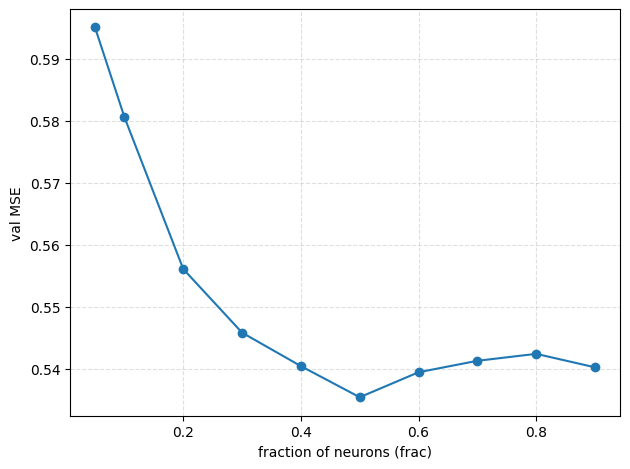

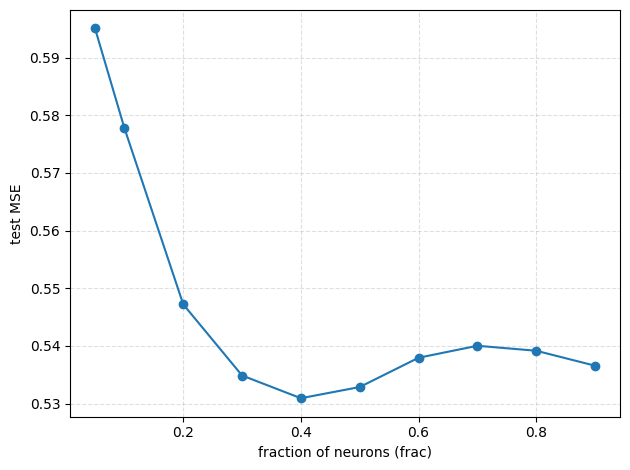

In [26]:
# Plots
def plot_xy(x, y, ylabel, fname, save_fig=False):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel("fraction of neurons (frac)")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_fig:
        outp = os.path.join(save_dir, fname)
        plt.savefig(outp, dpi=160)
        print(f"[ok] saved plot -> {outp}")
    plt.show()
    plt.close()

plot_xy(best_df["frac"], best_df["final_val_mse"], "val MSE", "val_mse_vs_frac.png")
plot_xy(best_df["frac"], best_df["final_test_mse"], "test MSE", "test_mse_vs_frac.png")

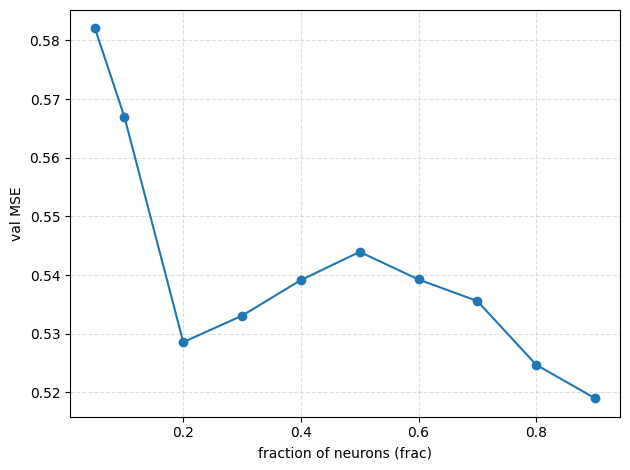

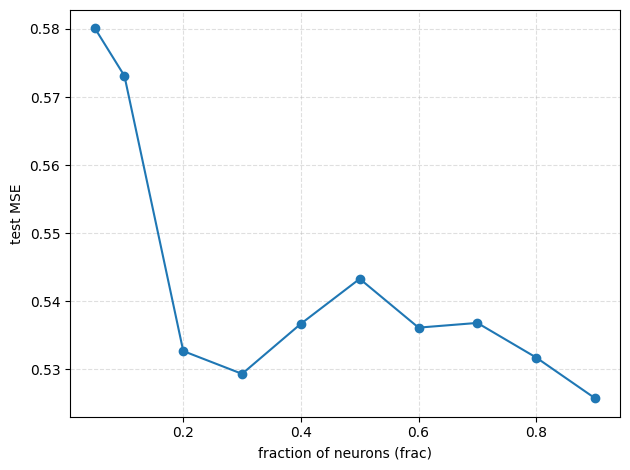

In [30]:
# Plots
def plot_xy(x, y, ylabel, fname, save_fig=False):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel("fraction of neurons (frac)")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_fig:
        outp = os.path.join(save_dir, fname)
        plt.savefig(outp, dpi=160)
        print(f"[ok] saved plot -> {outp}")
    plt.show()
    plt.close()

plot_xy(best_df["frac"], best_df["final_val_mse"], "val MSE", "val_mse_vs_frac.png")
plot_xy(best_df["frac"], best_df["final_test_mse"], "test MSE", "test_mse_vs_frac.png")